# 08 Full-Text Incumbent Similarity Experiment

This notebook extends the structured similarity experiment from Notebook 06 into the full-text NLP setting.

Notebook 07 compared full-text candidate resumes to a job description. This notebook compares those same full-text candidate resumes to full-text resumes generated for the structured reference population from Notebook 06.

The purpose is to test whether the screening target changes the apparent fairness outcome:

- **Job-description similarity:** Does the resume match the stated role requirements?
- **Incumbent-profile similarity:** Does the resume resemble the existing / successful employee reference population?

The working hypothesis is that senior candidates may score well against a job description while scoring lower against an incumbent profile if the reference population is concentrated around mid-career, less senior employee profiles.

## Reading Guide

This notebook should be read as the full-text counterpart to Notebook 06 and as a contrast to Notebook 07.

Notebook 07 asks whether candidate resumes match the job description. This notebook asks whether those same candidates resemble the reference employee population. The distinction is important because the comparison target can change which candidates appear strongest: a senior candidate may match the job description well while appearing less similar to a mid-career incumbent profile.

The main interpretation is reserved for Section 11 after the similarity and screen-in results are shown.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

ROOT = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
DATA_DIR = ROOT / "data"
EXPERIMENTS_DIR = DATA_DIR / "experiments"
REPORTS_DIR = ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AGE_GROUP_ORDER = ["<30", "30-39", "40-49", "50-59", "60+"]

modes = [
    "with_proxies",
    "without_direct_age_proxies",
    "minimal_proxy",
]

ROOT

PosixPath('/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter')

## 1. Required input files

This notebook expects two sets of generated full-text resumes.

Candidate resumes from Notebook 07:

- `data/experiments/synthetic_resumes_balanced_1000_fulltext_with_proxies.csv`
- `data/experiments/synthetic_resumes_balanced_1000_fulltext_without_direct_age_proxies.csv`
- `data/experiments/synthetic_resumes_balanced_1000_fulltext_minimal_proxy.csv`

Reference employee resumes generated from the Notebook 06 reference population:

- `data/experiments/synthetic_reference_employees_500_fulltext_with_proxies.csv`
- `data/experiments/synthetic_reference_employees_500_fulltext_without_direct_age_proxies.csv`
- `data/experiments/synthetic_reference_employees_500_fulltext_minimal_proxy.csv`

If the reference full-text files do not exist yet, first run:

```bash
for MODE in with_proxies without_direct_age_proxies minimal_proxy; do
  python src/llm_resume_generation.py \
    --input data/experiments/synthetic_reference_employees_500.parquet \
    --output data/experiments/synthetic_reference_employees_500_fulltext_${MODE}.csv \
    --mode ${MODE} \
    --overwrite
done
```

## 2. Load candidate and reference full-text resumes

In [2]:
candidate_template = "synthetic_resumes_balanced_1000_fulltext_{mode}.csv"
reference_template = "synthetic_reference_employees_500_fulltext_{mode}.csv"

candidate_frames = []
reference_frames = []
missing = []

for mode in modes:
    candidate_path = EXPERIMENTS_DIR / candidate_template.format(mode=mode)
    reference_path = EXPERIMENTS_DIR / reference_template.format(mode=mode)

    if not candidate_path.exists():
        missing.append(candidate_path)
    else:
        df_candidate = pd.read_csv(candidate_path)
        df_candidate["generation_mode"] = mode
        df_candidate["source_file"] = candidate_path.name
        df_candidate["population"] = "candidate"
        candidate_frames.append(df_candidate)

    if not reference_path.exists():
        missing.append(reference_path)
    else:
        df_reference = pd.read_csv(reference_path)
        df_reference["generation_mode"] = mode
        df_reference["source_file"] = reference_path.name
        df_reference["population"] = "reference_employee"
        reference_frames.append(df_reference)

if missing:
    print("Missing files:")
    for path in missing:
        print(" -", path)
    raise FileNotFoundError("One or more full-text candidate/reference files are missing.")

candidates = pd.concat(candidate_frames, ignore_index=True)
references = pd.concat(reference_frames, ignore_index=True)

for df_ in [candidates, references]:
    df_["age_group"] = pd.Categorical(
        df_["age_group"].astype(str),
        categories=AGE_GROUP_ORDER,
        ordered=True,
    )

print("Candidates:", candidates.shape)
print("References:", references.shape)

display(candidates[["candidate_id", "age_group", "generation_mode", "resume_text"]].head())
display(references[["candidate_id", "age_group", "generation_mode", "resume_text"]].head())

Candidates: (3000, 69)
References: (1500, 69)


,candidate_id,age_group,generation_mode,resume_text
0,cand_009330,<30,with_proxies,"Emerson Chen\n\nSummary \nAspiring software engineer with a PhD and a strong foundation in programming and cloud technologies. Experienced in Python, JavaScript, and Go, with a focus on machine l..."
1,cand_007473,<30,with_proxies,"Riley Nguyen\n\nSummary \nMotivated software engineer with a foundational background in programming and cloud technologies. Eager to leverage skills in Python, JavaScript, and cloud platforms to ..."
2,cand_003605,<30,with_proxies,"Quinn Hall\n\nSummary \nMotivated software engineer with experience in Python, JavaScript, and cloud technologies. Proven ability to adapt and learn quickly, with a strong foundation in software ..."
3,cand_009055,<30,with_proxies,Alex Moore\n\nSummary \nDetail-oriented software engineer with nearly 4 years of experience in developing and maintaining applications. Proficient in a variety of programming languages and cloud ...
4,cand_005128,<30,with_proxies,"Quinn Martinez\n\nSummary \nAspiring software engineer with a PhD and a strong foundation in programming and cloud technologies. Proficient in Python, Java, AWS, Spark, and Terraform. Eager to co..."


,candidate_id,age_group,generation_mode,resume_text
0,cand_003527,30-39,with_proxies,"Taylor Thomas\n\nSummary \nSoftware Engineer with over 10 years of experience, including 9 years in relevant roles. Proven track record in leading teams and managing projects, with a focus on del..."
1,cand_006401,40-49,with_proxies,"Logan Patel\n\nSummary \nSoftware engineer with over 11 years of experience, including 8 years in relevant roles. Proven expertise in Java, JavaScript, and cloud technologies. Strong background i..."
2,cand_004217,40-49,with_proxies,"Quinn Wilson\n\nSummary \nResults-driven Senior Engineer with over 9 years of experience in software development, specializing in data solutions. Proven track record in leading teams and managing..."
3,cand_003911,30-39,with_proxies,"Quinn Nguyen\n\nSummary \nSoftware engineer with over 7 years of experience, specializing in Python, Go, SQL, Spark, and Terraform. Proven ability to lead projects and deliver high-quality soluti..."
4,cand_000416,30-39,with_proxies,"Kai Moore\n\nSummary \nSoftware engineer with over 11 years of experience, including 8 years in relevant roles. Proven expertise in Python, Kubernetes, AWS, Azure, and Linux. Strong leadership sk..."


## 3. Generation health checks

In [3]:
def generation_health(df: pd.DataFrame, population_label: str) -> pd.DataFrame:
    out = (
        df
        .assign(
            has_resume_text=df["resume_text"].fillna("").str.strip().ne(""),
            has_generation_error=df["generation_error"].fillna("").str.strip().ne(""),
            generated_word_count=df["resume_text"].fillna("").str.split().str.len(),
            generated_char_count=df["resume_text"].fillna("").str.len(),
        )
        .groupby("generation_mode", observed=True)
        .agg(
            rows=("candidate_id", "count"),
            unique_candidates=("candidate_id", "nunique"),
            nonempty_resumes=("has_resume_text", "sum"),
            generation_error_rows=("has_generation_error", "sum"),
            mean_generated_words=("generated_word_count", "mean"),
            median_generated_words=("generated_word_count", "median"),
            min_generated_words=("generated_word_count", "min"),
            max_generated_words=("generated_word_count", "max"),
        )
        .reset_index()
    )
    out.insert(0, "population", population_label)
    return out

health_summary = pd.concat([
    generation_health(candidates, "candidate"),
    generation_health(references, "reference_employee"),
], ignore_index=True)

health_summary.to_csv(TABLES_DIR / "fulltext_incumbent_generation_health_summary.csv", index=False)
health_summary

,population,generation_mode,rows,unique_candidates,nonempty_resumes,generation_error_rows,mean_generated_words,median_generated_words,min_generated_words,max_generated_words
0,candidate,minimal_proxy,1000,1000,1000,0,73.885,74.0,51,130
1,candidate,with_proxies,1000,1000,1000,0,108.849,109.0,57,158
2,candidate,without_direct_age_proxies,1000,1000,1000,0,108.905,109.0,62,160
3,reference_employee,minimal_proxy,500,500,500,0,75.506,75.0,54,126
4,reference_employee,with_proxies,500,500,500,0,114.016,114.0,84,157
5,reference_employee,without_direct_age_proxies,500,500,500,0,113.730,114.0,80,149


## 4. Leakage and placeholder audit

This mirrors the audit from Notebook 07 and checks both candidate and reference full-text resumes.

In [4]:
audit_patterns = {
    "bracket_placeholder": r"\[[^\]]+\]",
    "unspecified_or_not_provided": r"\b(?:unspecified|not provided|details not provided)\b",
    "company_school_placeholder": r"\b(?:Company Name|School Name)\b",
    "url_placeholder": r"\b(?:GitHub URL present|Portfolio URL present|GitHub URL|Portfolio URL)\b",
    "numbered_certification": r"\bCertification\s+[0-9]+\b",
    "project_details_placeholder": r"\bProject details\b",
    "highest_degree_none": r"Highest Degree:\s*None",
    "protected_field_terms": r"\b(?:true_age|age_group|protected class|protected field|fairness analysis)\b",
    "outcome_label_terms": r"\b(?:callback|interview label|offer label|target label)\b",
    "explicit_age_phrase": r"\b[0-9]{2}\s*(?:years old|year-old)\b",
}

audit_rows = []

for population_label, df_pop in [
    ("candidate", candidates),
    ("reference_employee", references),
]:
    for mode, df_mode in df_pop.groupby("generation_mode", observed=True):
        texts = df_mode["resume_text"].fillna("")
        for label, pattern in audit_patterns.items():
            mask = texts.str.contains(pattern, case=False, regex=True, na=False)
            audit_rows.append({
                "population": population_label,
                "generation_mode": mode,
                "audit_pattern": label,
                "hit_rows": int(mask.sum()),
                "hit_rate": float(mask.mean()),
            })

audit_summary = pd.DataFrame(audit_rows)
audit_summary.to_csv(TABLES_DIR / "fulltext_incumbent_leakage_placeholder_audit.csv", index=False)
audit_summary


,population,generation_mode,audit_pattern,hit_rows,hit_rate
0,candidate,minimal_proxy,bracket_placeholder,0,0.0
1,candidate,minimal_proxy,unspecified_or_not_provided,0,0.0
2,candidate,minimal_proxy,company_school_placeholder,0,0.0
3,candidate,minimal_proxy,url_placeholder,0,0.0
4,candidate,minimal_proxy,numbered_certification,0,0.0
5,candidate,minimal_proxy,project_details_placeholder,0,0.0
6,candidate,minimal_proxy,highest_degree_none,0,0.0
7,candidate,minimal_proxy,protected_field_terms,0,0.0
8,candidate,minimal_proxy,outcome_label_terms,0,0.0
9,candidate,minimal_proxy,explicit_age_phrase,0,0.0


In [5]:
# Display examples only if there are audit hits.
combined_for_audit = pd.concat([candidates, references], ignore_index=True)

for label, pattern in audit_patterns.items():
    hits = combined_for_audit[
        combined_for_audit["resume_text"].fillna("").str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
    ]
    if len(hits):
        print("\n" + "=" * 90)
        print(label, "| rows:", len(hits))
        print("=" * 90)
        display(hits[["population", "candidate_id", "age_group", "generation_mode", "resume_text"]].head(5))

## 5. Reference population composition

The reference set comes from Notebook 06 and is intentionally constrained to represent a mid-career, modern-technology-oriented success profile. This section checks its age distribution after full-text generation.

In [6]:
reference_composition = (
    references
    .groupby(["generation_mode", "age_group"], observed=True)
    .agg(
        reference_rows=("candidate_id", "count"),
        mean_years_experience_relevant=("years_experience_relevant", "mean"),
        mean_management_years=("management_years", "mean"),
        mean_modern_tech_count=("modern_tech_count", "mean"),
        mean_legacy_tech_count=("legacy_tech_count", "mean"),
    )
    .reset_index()
)

reference_composition.to_csv(TABLES_DIR / "fulltext_reference_employee_composition_by_mode_age.csv", index=False)
reference_composition

,generation_mode,age_group,reference_rows,mean_years_experience_relevant,mean_management_years,mean_modern_tech_count,mean_legacy_tech_count
0,minimal_proxy,<30,11,6.729945,2.022985,4.545455,0.000000
1,minimal_proxy,30-39,290,7.628989,2.175454,4.217241,0.462069
2,minimal_proxy,40-49,198,8.492343,2.320789,3.626263,0.853535
3,minimal_proxy,50-59,1,9.547490,2.254229,3.000000,1.000000
4,with_proxies,<30,11,6.729945,2.022985,4.545455,0.000000
5,with_proxies,30-39,290,7.628989,2.175454,4.217241,0.462069
6,with_proxies,40-49,198,8.492343,2.320789,3.626263,0.853535
7,with_proxies,50-59,1,9.547490,2.254229,3.000000,1.000000
8,without_direct_age_proxies,<30,11,6.729945,2.022985,4.545455,0.000000
9,without_direct_age_proxies,30-39,290,7.628989,2.175454,4.217241,0.462069


## 6. Embed candidate and reference resumes

This section uses the same embedding model as Notebook 07 so that job-description similarity and incumbent-profile similarity are comparable.

In [7]:
try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "sentence-transformers is required for this notebook. "
        "Install it with: pip install sentence-transformers"
    ) from exc

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
EMBEDDING_MODEL_NAME

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

'sentence-transformers/all-MiniLM-L6-v2'

In [8]:
# Encode by generation mode to avoid comparing text generated under different information conditions.
candidate_embeddings_by_mode = {}
reference_embeddings_by_mode = {}

for mode in modes:
    candidate_texts = (
        candidates[candidates["generation_mode"] == mode]
        .sort_values("candidate_id")["resume_text"]
        .fillna("")
        .tolist()
    )
    reference_texts = (
        references[references["generation_mode"] == mode]
        .sort_values("candidate_id")["resume_text"]
        .fillna("")
        .tolist()
    )

    print(f"Encoding mode={mode}: candidates={len(candidate_texts)}, references={len(reference_texts)}")

    candidate_embeddings_by_mode[mode] = embedding_model.encode(
        candidate_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    reference_embeddings_by_mode[mode] = embedding_model.encode(
        reference_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

Encoding mode=with_proxies: candidates=1000, references=500


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding mode=without_direct_age_proxies: candidates=1000, references=500


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding mode=minimal_proxy: candidates=1000, references=500


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

## 7. Compute candidate-to-reference similarity

For each candidate, this notebook computes three similarity measures:

- `mean_reference_similarity`: average similarity to all reference employee resumes.
- `max_reference_similarity`: similarity to the single nearest reference employee resume.
- `top10_reference_similarity`: average similarity to the 10 nearest reference employee resumes.

The `top10_reference_similarity` metric is often the most useful analogy for nearest-neighbor style candidate matching.

In [9]:
scored_frames = []

for mode in modes:
    candidate_mode = (
        candidates[candidates["generation_mode"] == mode]
        .sort_values("candidate_id")
        .reset_index(drop=True)
        .copy()
    )
    reference_mode = (
        references[references["generation_mode"] == mode]
        .sort_values("candidate_id")
        .reset_index(drop=True)
        .copy()
    )

    candidate_embeddings = candidate_embeddings_by_mode[mode]
    reference_embeddings = reference_embeddings_by_mode[mode]

    sims = cosine_similarity(candidate_embeddings, reference_embeddings)

    top_k = min(10, sims.shape[1])
    top_k_mean = np.sort(sims, axis=1)[:, -top_k:].mean(axis=1)

    candidate_mode["mean_reference_similarity"] = sims.mean(axis=1)
    candidate_mode["max_reference_similarity"] = sims.max(axis=1)
    candidate_mode["top10_reference_similarity"] = top_k_mean
    candidate_mode["reference_count"] = sims.shape[1]
    candidate_mode["top_k"] = top_k
    candidate_mode["embedding_model"] = EMBEDDING_MODEL_NAME

    scored_frames.append(candidate_mode)

incumbent_similarity = pd.concat(scored_frames, ignore_index=True)

score_cols = [
    "candidate_id",
    "age_group",
    "generation_mode",
    "mean_reference_similarity",
    "max_reference_similarity",
    "top10_reference_similarity",
]
incumbent_similarity[score_cols].head()

,candidate_id,age_group,generation_mode,mean_reference_similarity,max_reference_similarity,top10_reference_similarity
0,cand_000000,30-39,with_proxies,0.745070,0.874954,0.855293
1,cand_000007,60+,with_proxies,0.649566,0.860544,0.801774
2,cand_000054,50-59,with_proxies,0.688949,0.861515,0.831412
3,cand_000061,60+,with_proxies,0.659040,0.852155,0.807780
4,cand_000085,50-59,with_proxies,0.630977,0.882854,0.791906


## 8. Similarity summaries by age group and mode

In [10]:
similarity_metrics = [
    "mean_reference_similarity",
    "max_reference_similarity",
    "top10_reference_similarity",
]

summary_rows = []

for metric in similarity_metrics:
    metric_summary = (
        incumbent_similarity
        .groupby(["generation_mode", "age_group"], observed=True)
        .agg(
            rows=("candidate_id", "count"),
            mean_score=(metric, "mean"),
            median_score=(metric, "median"),
            std_score=(metric, "std"),
            min_score=(metric, "min"),
            max_score=(metric, "max"),
        )
        .reset_index()
    )
    metric_summary.insert(0, "similarity_metric", metric)
    summary_rows.append(metric_summary)

incumbent_similarity_by_mode_age = pd.concat(summary_rows, ignore_index=True)
incumbent_similarity_by_mode_age.to_csv(
    TABLES_DIR / "fulltext_incumbent_similarity_by_mode_age.csv",
    index=False,
)

incumbent_similarity_by_mode_age

,similarity_metric,generation_mode,age_group,rows,mean_score,median_score,std_score,min_score,max_score
0,mean_reference_similarity,minimal_proxy,<30,200,0.704943,0.705539,0.033646,0.588110,0.772927
1,mean_reference_similarity,minimal_proxy,30-39,200,0.717831,0.719153,0.028184,0.646261,0.778541
2,mean_reference_similarity,minimal_proxy,40-49,200,0.711758,0.714134,0.033895,0.582637,0.774084
3,mean_reference_similarity,minimal_proxy,50-59,200,0.702387,0.704295,0.030627,0.595207,0.765173
4,mean_reference_similarity,minimal_proxy,60+,200,0.701547,0.705756,0.031690,0.602726,0.761439
5,mean_reference_similarity,with_proxies,<30,200,0.692979,0.696646,0.030183,0.591827,0.750515
6,mean_reference_similarity,with_proxies,30-39,200,0.700637,0.703919,0.031752,0.615223,0.761593
7,mean_reference_similarity,with_proxies,40-49,200,0.705047,0.710431,0.035103,0.583941,0.770537
8,mean_reference_similarity,with_proxies,50-59,200,0.701613,0.705950,0.034149,0.607097,0.769718
9,mean_reference_similarity,with_proxies,60+,200,0.690248,0.694664,0.034140,0.580978,0.768944


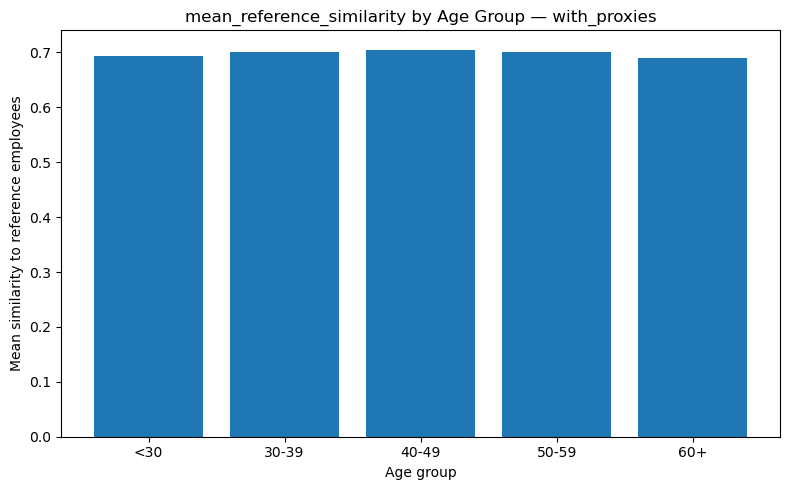

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_mean_reference_similarity_by_age_with_proxies.png


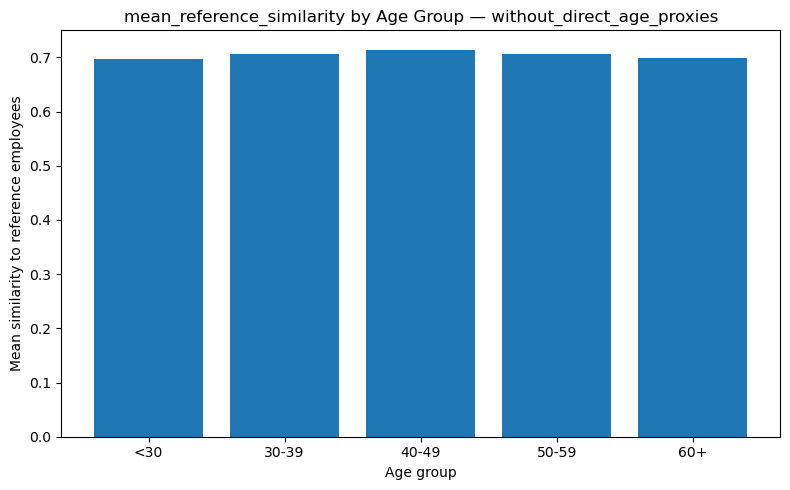

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_mean_reference_similarity_by_age_without_direct_age_proxies.png


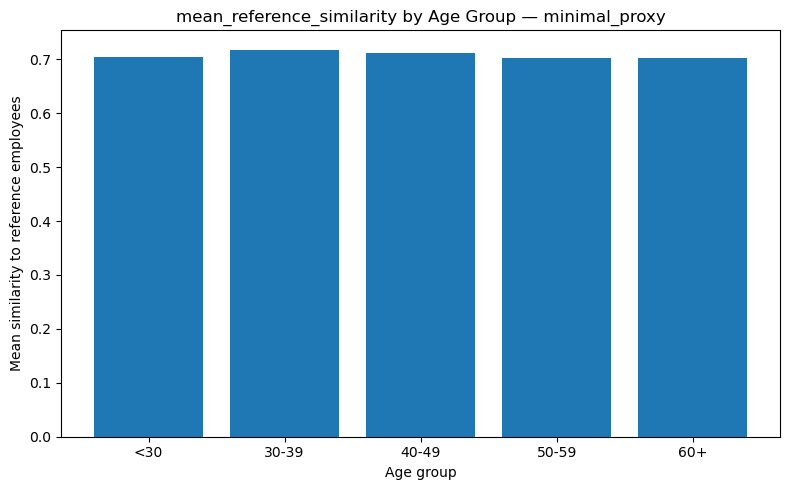

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_mean_reference_similarity_by_age_minimal_proxy.png


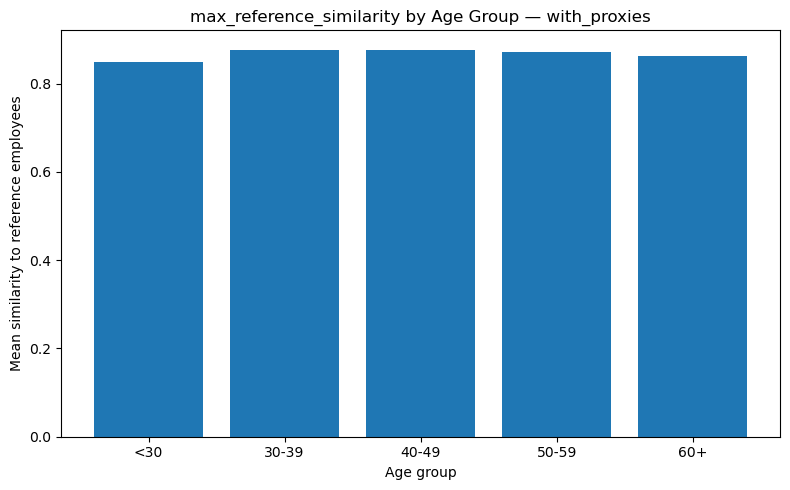

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_max_reference_similarity_by_age_with_proxies.png


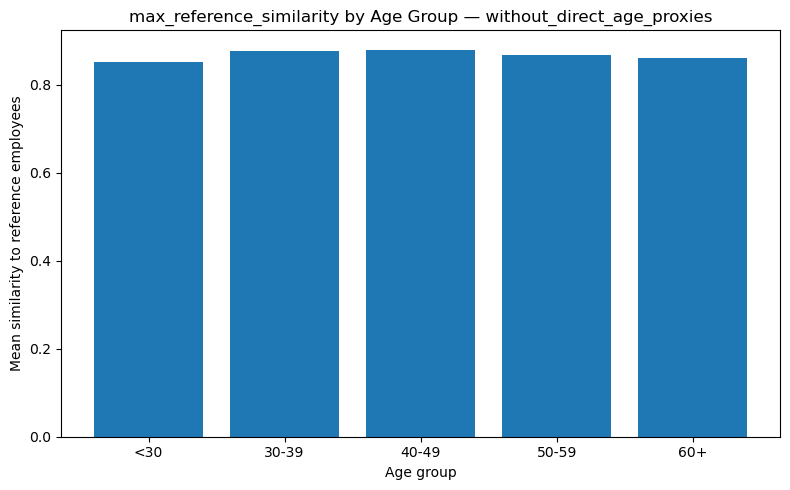

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_max_reference_similarity_by_age_without_direct_age_proxies.png


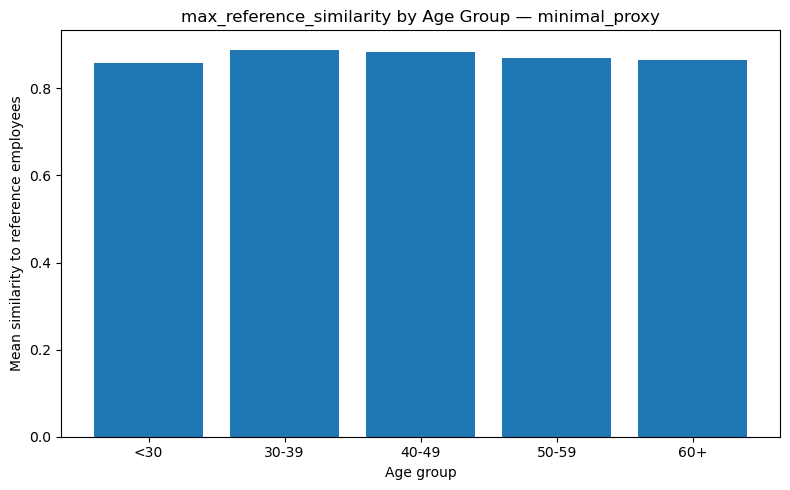

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_max_reference_similarity_by_age_minimal_proxy.png


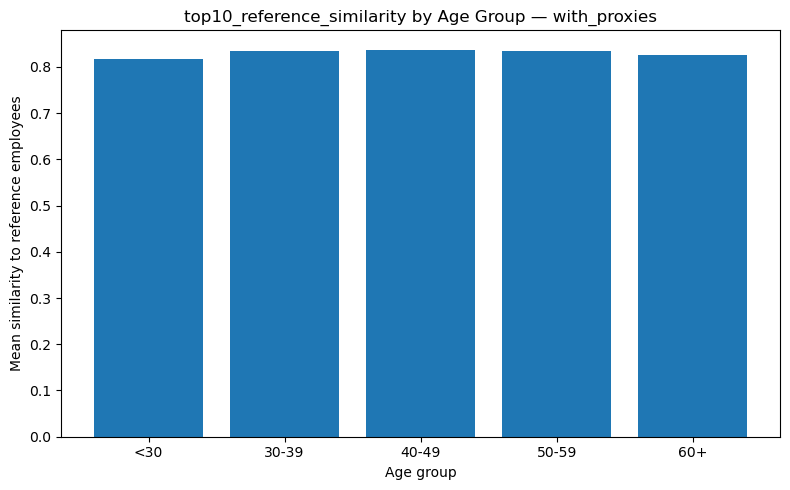

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_top10_reference_similarity_by_age_with_proxies.png


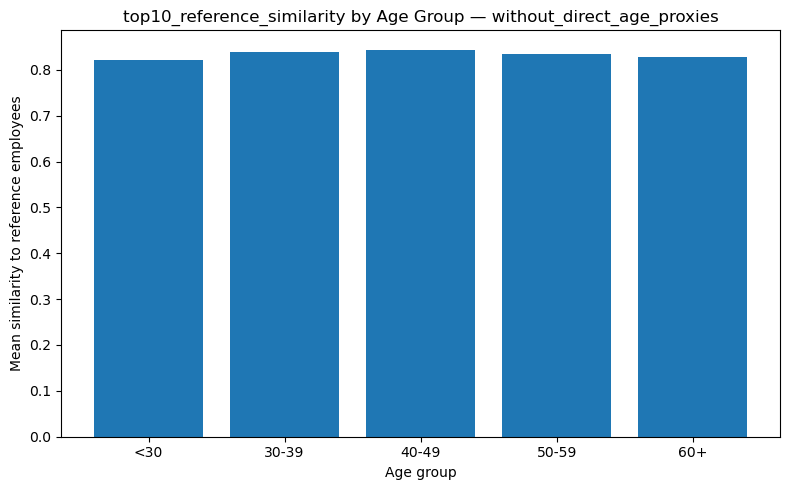

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_top10_reference_similarity_by_age_without_direct_age_proxies.png


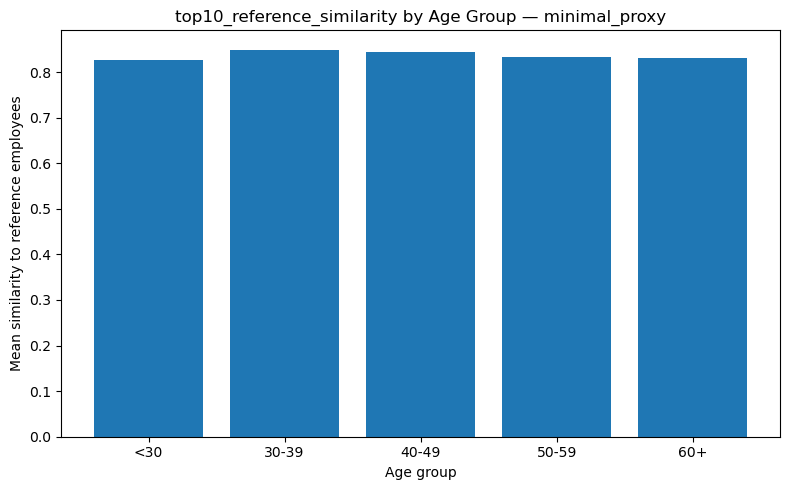

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_top10_reference_similarity_by_age_minimal_proxy.png


In [11]:
for metric in similarity_metrics:
    for mode in modes:
        plot_df = incumbent_similarity_by_mode_age[
            (incumbent_similarity_by_mode_age["similarity_metric"] == metric) &
            (incumbent_similarity_by_mode_age["generation_mode"] == mode)
        ].copy()

        plot_df["age_group"] = pd.Categorical(
            plot_df["age_group"].astype(str),
            categories=AGE_GROUP_ORDER,
            ordered=True,
        )
        plot_df = plot_df.sort_values("age_group")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(plot_df["age_group"].astype(str), plot_df["mean_score"])
        ax.set_title(f"{metric} by Age Group — {mode}")
        ax.set_xlabel("Age group")
        ax.set_ylabel("Mean similarity to reference employees")
        fig.tight_layout()

        out = FIGURES_DIR / f"fulltext_incumbent_{metric}_by_age_{mode}.png"
        fig.savefig(out, dpi=150)
        plt.show()
        print(out)

## 9. Screen-in rates using incumbent-profile similarity

The threshold is computed separately within each generation mode and similarity metric. This keeps the overall screen-in rate constant within each comparison and focuses the analysis on which age groups are over- or under-represented among the highest-similarity candidates.

In [12]:
SCREEN_RATE = 0.45
threshold_quantile = 1.0 - SCREEN_RATE

screen_frames = []

for metric in similarity_metrics:
    for mode, df_mode in incumbent_similarity.groupby("generation_mode", observed=True):
        df_screen = df_mode.copy()
        threshold = df_screen[metric].quantile(threshold_quantile)

        df_screen["screen_metric"] = metric
        df_screen["screen_threshold_quantile"] = threshold_quantile
        df_screen["screen_threshold"] = threshold
        df_screen["screened_in"] = df_screen[metric] >= threshold

        screen_frames.append(df_screen)

screen_df = pd.concat(screen_frames, ignore_index=True)

screen_rates = (
    screen_df
    .groupby(["screen_metric", "generation_mode", "age_group"], observed=True)
    .agg(
        rows=("candidate_id", "count"),
        screen_rate=("screened_in", "mean"),
        mean_score=("mean_reference_similarity", "mean"),
        mean_top10_score=("top10_reference_similarity", "mean"),
        mean_max_score=("max_reference_similarity", "mean"),
    )
    .reset_index()
)

screen_rates.to_csv(TABLES_DIR / "fulltext_incumbent_screen_rates_by_mode_age.csv", index=False)
screen_rates

,screen_metric,generation_mode,age_group,rows,screen_rate,mean_score,mean_top10_score,mean_max_score
0,max_reference_similarity,minimal_proxy,<30,200,0.310,0.704943,0.826349,0.857994
1,max_reference_similarity,minimal_proxy,30-39,200,0.600,0.717831,0.849129,0.888780
2,max_reference_similarity,minimal_proxy,40-49,200,0.540,0.711758,0.843600,0.882853
3,max_reference_similarity,minimal_proxy,50-59,200,0.450,0.702387,0.832566,0.869532
4,max_reference_similarity,minimal_proxy,60+,200,0.350,0.701547,0.829860,0.865882
5,max_reference_similarity,with_proxies,<30,200,0.220,0.692979,0.817805,0.848718
6,max_reference_similarity,with_proxies,30-39,200,0.560,0.700637,0.835038,0.876751
7,max_reference_similarity,with_proxies,40-49,200,0.555,0.705047,0.837182,0.876199
8,max_reference_similarity,with_proxies,50-59,200,0.515,0.701613,0.834024,0.871104
9,max_reference_similarity,with_proxies,60+,200,0.400,0.690248,0.825685,0.861950


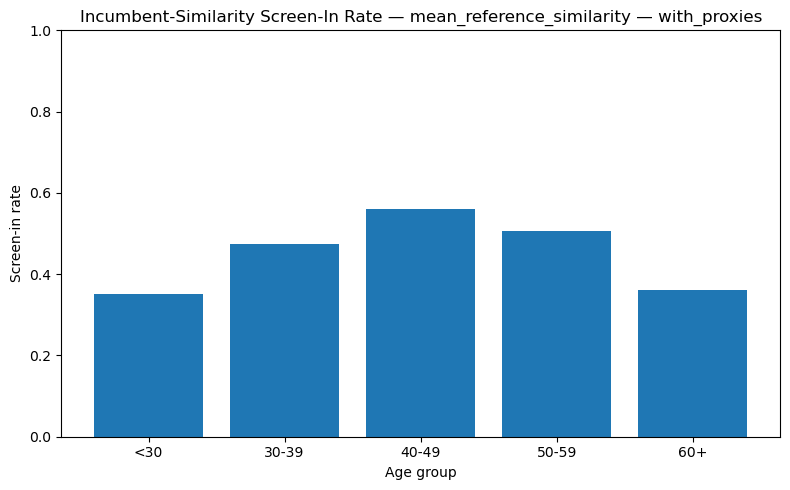

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_mean_reference_similarity_by_age_with_proxies.png


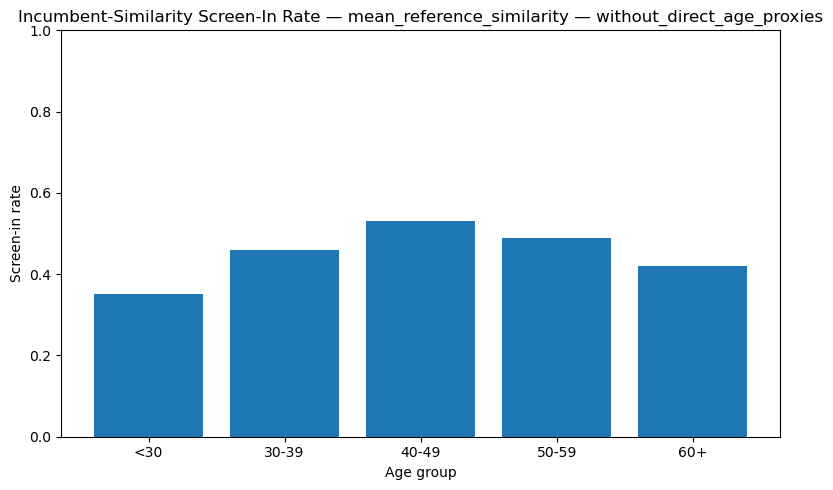

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_mean_reference_similarity_by_age_without_direct_age_proxies.png


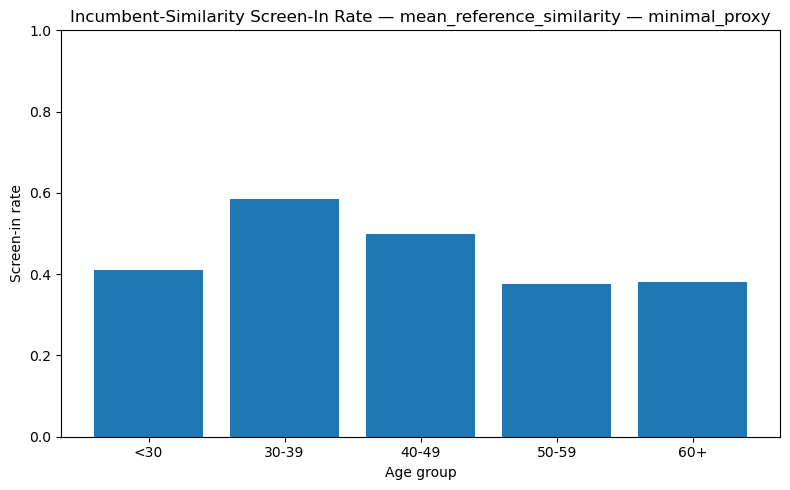

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_mean_reference_similarity_by_age_minimal_proxy.png


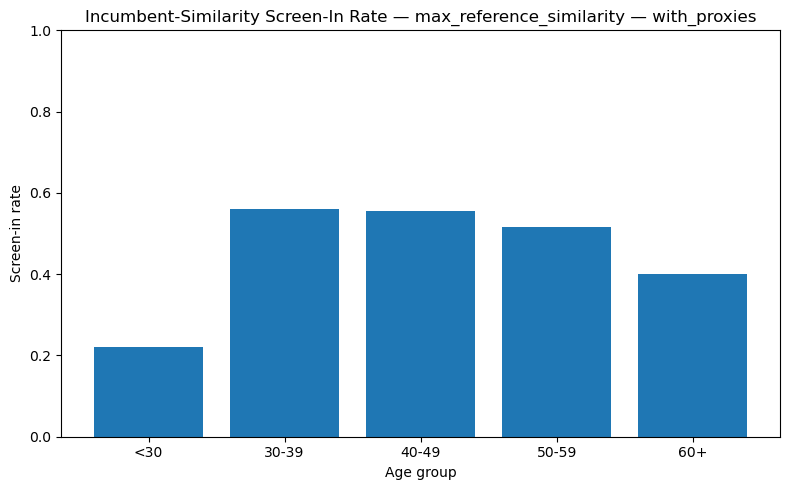

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_max_reference_similarity_by_age_with_proxies.png


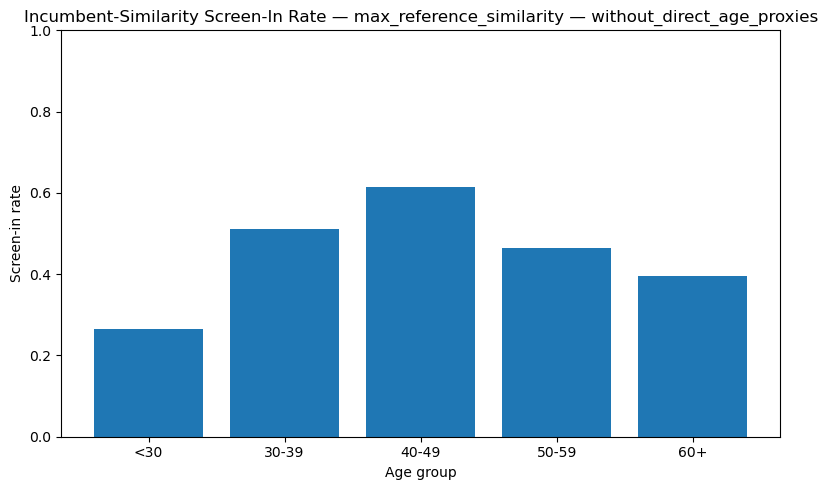

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_max_reference_similarity_by_age_without_direct_age_proxies.png


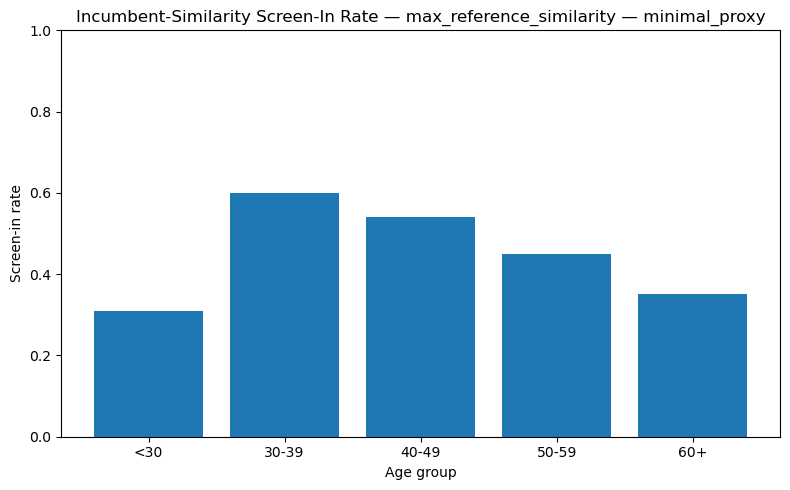

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_max_reference_similarity_by_age_minimal_proxy.png


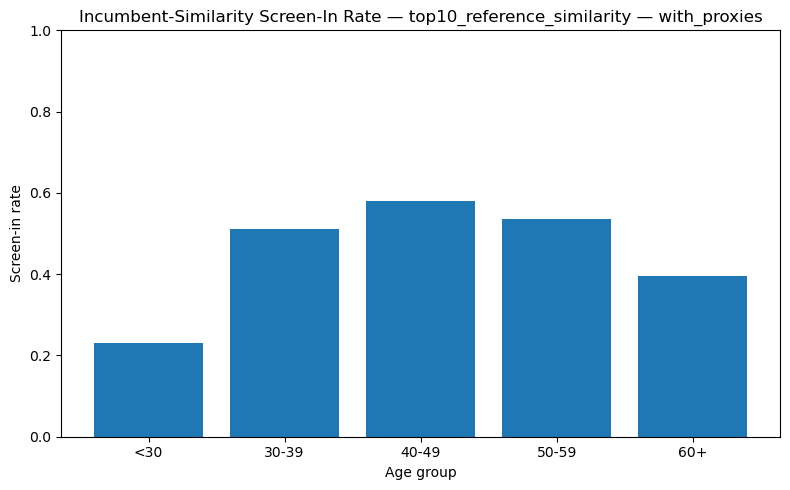

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_top10_reference_similarity_by_age_with_proxies.png


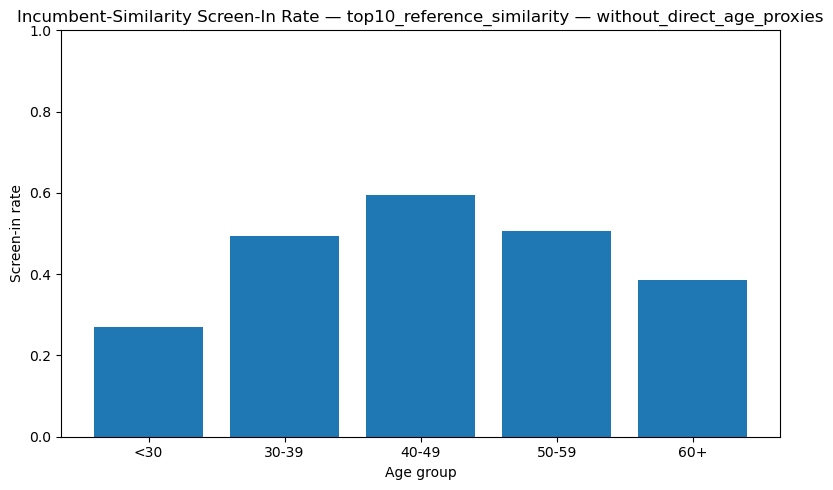

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_top10_reference_similarity_by_age_without_direct_age_proxies.png


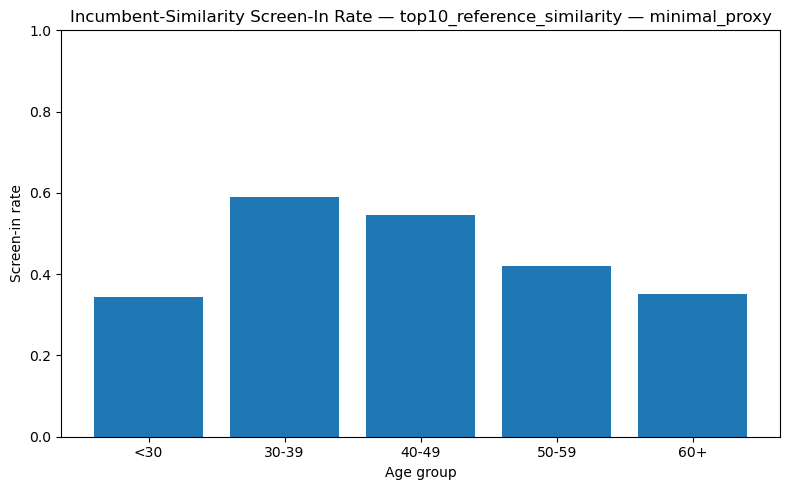

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/fulltext_incumbent_screen_rate_top10_reference_similarity_by_age_minimal_proxy.png


In [13]:
for metric in similarity_metrics:
    for mode in modes:
        plot_df = screen_rates[
            (screen_rates["screen_metric"] == metric) &
            (screen_rates["generation_mode"] == mode)
        ].copy()

        plot_df["age_group"] = pd.Categorical(
            plot_df["age_group"].astype(str),
            categories=AGE_GROUP_ORDER,
            ordered=True,
        )
        plot_df = plot_df.sort_values("age_group")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(plot_df["age_group"].astype(str), plot_df["screen_rate"])
        ax.set_title(f"Incumbent-Similarity Screen-In Rate — {metric} — {mode}")
        ax.set_xlabel("Age group")
        ax.set_ylabel("Screen-in rate")
        ax.set_ylim(0, 1)
        fig.tight_layout()

        out = FIGURES_DIR / f"fulltext_incumbent_screen_rate_{metric}_by_age_{mode}.png"
        fig.savefig(out, dpi=150)
        plt.show()
        print(out)

### Interpretation: Incumbent-Similarity Screening

The full-text incumbent-similarity experiment produces a different pattern from the job-description similarity experiment in Notebook 07. When candidates are compared directly to the job description, older and more senior candidates tend to score highly. When candidates are compared to the full-text resumes of the reference employee population, the highest screen-in rates shift toward the age groups that most closely resemble that reference population.

This is expected given the construction of the reference set. The reference employee population is concentrated in the 30-39 and 40-49 age groups and represents a mid-career profile: relevant experience, some management exposure, modern technical skills, and titles such as Senior Engineer, Staff Engineer, or Engineering Manager. As a result, candidates in the 30-39 and 40-49 groups generally have the highest incumbent-similarity screen-in rates.

This result supports the core mechanism tested by the project. The fairness concern is not simply whether an AI system can recognize experienced candidates as qualified. In the job-description similarity experiment, senior candidates perform well. The concern is that systems optimized to reproduce the profile of existing employees or historical hires may penalize candidates who differ from that profile, even if they are highly qualified for the role.

In this experiment, the same seniority signals that improve job-description relevance do not necessarily improve incumbent-profile similarity. Candidates who are too junior or too senior relative to the reference population are less likely to be selected by an incumbent-similarity screen.

## 10. Compare job-description similarity against incumbent-profile similarity

Notebook 07 scores each candidate against the job description. This section loads the Notebook 07 scored dataset, when available, and compares it to incumbent-profile similarity.

The loader checks for either:

- `data/experiments/synthetic_resumes_balanced_1000_fulltext_scored.csv`
- `data/experiments/synthetic_resumes_balanced_1000_fulltext_scored.parquet`

The goal is to show whether the same candidate can appear strong against the job description but less similar to the reference employee population.


In [14]:
jobdesc_score_candidates = [
    EXPERIMENTS_DIR / "synthetic_resumes_balanced_1000_fulltext_scored.csv",
    EXPERIMENTS_DIR / "synthetic_resumes_balanced_1000_fulltext_scored.parquet",
]

jobdesc_scores_path = next(
    (path for path in jobdesc_score_candidates if path.exists()),
    None,
)

if jobdesc_scores_path is not None:
    if jobdesc_scores_path.suffix.lower() == ".csv":
        jobdesc_scores = pd.read_csv(jobdesc_scores_path)
    else:
        jobdesc_scores = pd.read_parquet(jobdesc_scores_path)

    print("Loaded:", jobdesc_scores_path)
    print(jobdesc_scores.shape)
else:
    jobdesc_scores = None
    print("Notebook 07 scored dataset not found. Checked:")
    for path in jobdesc_score_candidates:
        print(" -", path)
    print("This comparison section can be rerun after Notebook 07 exports the scored dataset.")


Loaded: /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/experiments/synthetic_resumes_balanced_1000_fulltext_scored.csv
(3000, 74)


In [18]:
if jobdesc_scores is not None:
    # Support either the Notebook 07 column name or a generic fallback.
    if "nlp_similarity_score" not in jobdesc_scores.columns:
        if "similarity_score" in jobdesc_scores.columns:
            jobdesc_scores = jobdesc_scores.rename(
                columns={"similarity_score": "nlp_similarity_score"}
            )
        else:
            raise KeyError(
                "Notebook 07 scored dataset must contain either "
                "'nlp_similarity_score' or 'similarity_score'. "
                f"Available columns: {list(jobdesc_scores.columns)}"
            )

    compare_cols = [
        "candidate_id",
        "generation_mode",
        "age_group",
        "nlp_similarity_score",
    ]

    comparison = incumbent_similarity.merge(
        jobdesc_scores[compare_cols],
        on=["candidate_id", "generation_mode", "age_group"],
        how="inner",
    )

    if comparison.empty:
        raise ValueError(
            "No rows matched between incumbent_similarity and Notebook 07 scores. "
            "Check candidate_id, generation_mode, and age_group values."
        )

    # Compare relative standing within each generation mode, not raw cosine values.
    comparison["jobdesc_similarity_percentile"] = (
        comparison
        .groupby("generation_mode", observed=True)["nlp_similarity_score"]
        .rank(pct=True)
    )

    comparison["top10_incumbent_similarity_percentile"] = (
        comparison
        .groupby("generation_mode", observed=True)["top10_reference_similarity"]
        .rank(pct=True)
    )

    comparison["jobdesc_minus_incumbent_percentile"] = (
        comparison["jobdesc_similarity_percentile"]
        - comparison["top10_incumbent_similarity_percentile"]
    )

    # Match the same 45% screen-in rate used elsewhere.
    screen_rate = 0.45
    threshold_quantile = 1.0 - screen_rate

    comparison["jobdesc_screened_in"] = (
        comparison
        .groupby("generation_mode", observed=True)["nlp_similarity_score"]
        .transform(lambda s: s >= s.quantile(threshold_quantile))
    )

    comparison["incumbent_screened_in"] = (
        comparison
        .groupby("generation_mode", observed=True)["top10_reference_similarity"]
        .transform(lambda s: s >= s.quantile(threshold_quantile))
    )

    comparison["screening_outcome"] = np.select(
        [
            comparison["jobdesc_screened_in"] & comparison["incumbent_screened_in"],
            comparison["jobdesc_screened_in"] & ~comparison["incumbent_screened_in"],
            ~comparison["jobdesc_screened_in"] & comparison["incumbent_screened_in"],
        ],
        [
            "screened_by_both",
            "jobdesc_only",
            "incumbent_only",
        ],
        default="screened_by_neither",
    )

    target_comparison_by_age = (
        comparison
        .groupby(["generation_mode", "age_group"], observed=True)
        .agg(
            rows=("candidate_id", "count"),
            mean_jobdesc_percentile=("jobdesc_similarity_percentile", "mean"),
            mean_incumbent_percentile=("top10_incumbent_similarity_percentile", "mean"),
            mean_jobdesc_minus_incumbent_percentile=("jobdesc_minus_incumbent_percentile", "mean"),
            jobdesc_screen_rate=("jobdesc_screened_in", "mean"),
            incumbent_screen_rate=("incumbent_screened_in", "mean"),
        )
        .reset_index()
    )

    outcome_mix_by_age = (
        comparison
        .groupby(["generation_mode", "age_group", "screening_outcome"], observed=True)
        .size()
        .reset_index(name="rows")
    )

    outcome_mix_by_age["share"] = (
        outcome_mix_by_age["rows"]
        / outcome_mix_by_age
            .groupby(["generation_mode", "age_group"], observed=True)["rows"]
            .transform("sum")
    )

    target_comparison_by_age.to_csv(
        TABLES_DIR / "fulltext_jobdesc_vs_incumbent_similarity_by_age.csv",
        index=False,
    )

    outcome_mix_by_age.to_csv(
        TABLES_DIR / "fulltext_jobdesc_vs_incumbent_screening_outcome_mix_by_age.csv",
        index=False,
    )

    comparison.to_parquet(
        EXPERIMENTS_DIR / "fulltext_jobdesc_vs_incumbent_candidate_comparison.parquet",
        index=False,
    )

    display(target_comparison_by_age)
    display(outcome_mix_by_age)
else:
    print("Skipping comparison because job-description scored dataset is unavailable.")

,generation_mode,age_group,rows,mean_jobdesc_percentile,mean_incumbent_percentile,mean_jobdesc_minus_incumbent_percentile,jobdesc_screen_rate,incumbent_screen_rate
0,minimal_proxy,30-39,200,0.382605,0.623720,-0.241115,0.265,0.590
1,minimal_proxy,40-49,200,0.483400,0.571775,-0.088375,0.420,0.545
2,minimal_proxy,50-59,200,0.610980,0.464452,0.146528,0.630,0.420
3,minimal_proxy,60+,200,0.635415,0.429000,0.206415,0.645,0.350
4,minimal_proxy,<30,200,0.390100,0.413552,-0.023453,0.290,0.345
5,with_proxies,30-39,200,0.395380,0.557370,-0.161990,0.305,0.510
6,with_proxies,40-49,200,0.537195,0.582998,-0.045802,0.510,0.580
7,with_proxies,50-59,200,0.637240,0.547290,0.089950,0.640,0.535
8,with_proxies,60+,200,0.584115,0.450345,0.133770,0.575,0.395
9,with_proxies,<30,200,0.348570,0.364498,-0.015928,0.220,0.230


,generation_mode,age_group,screening_outcome,rows,share
0,minimal_proxy,30-39,incumbent_only,81,0.405
1,minimal_proxy,30-39,jobdesc_only,16,0.080
2,minimal_proxy,30-39,screened_by_both,37,0.185
3,minimal_proxy,30-39,screened_by_neither,66,0.330
4,minimal_proxy,40-49,incumbent_only,51,0.255
5,minimal_proxy,40-49,jobdesc_only,26,0.130
6,minimal_proxy,40-49,screened_by_both,58,0.290
7,minimal_proxy,40-49,screened_by_neither,65,0.325
8,minimal_proxy,50-59,incumbent_only,20,0.100
9,minimal_proxy,50-59,jobdesc_only,62,0.310


## 11. Interpretation

This full-text incumbent-similarity experiment produces a different pattern from the job-description similarity experiment in Notebook 07.

In Notebook 07, candidates were evaluated against the job description. Under that comparison target, older and more senior candidates tended to perform well because their resumes contained more experience, broader technical coverage, leadership signals, and other role-relevant qualifications.

In this notebook, the comparison target is different. Candidates are evaluated against the full-text resumes of a synthetic reference population representing existing or successful employees. That reference population is concentrated in the 30-39 and 40-49 age groups and reflects a mid-career profile: relevant experience, some management exposure, modern technical skills, and titles such as Senior Engineer, Staff Engineer, or Engineering Manager.

Among the three incumbent-similarity metrics, `top10_reference_similarity` is the primary metric for interpretation. The mean similarity score can wash out nearest-neighbor effects by averaging across the full reference population, while max similarity can be overly sensitive to a single unusually close reference resume. The top-10 metric is a middle ground: it approximates a nearest-neighbor screening process while being less brittle than a single maximum match.

The results show that incumbent-similarity screening tends to favor candidates who resemble that reference population. The strongest screen-in rates generally shift toward the mid-career groups rather than the oldest groups. Candidates under 30 appear less similar because they are often too junior. Candidates in the 50-59 and 60+ groups may still have strong qualifications, but they are less consistently similar to the reference population because their resumes often contain more seniority, broader leadership signals, or career-stage attributes outside the target profile.

This distinction is the main finding of the experiment. The issue is not that NLP models are incapable of recognizing senior candidates as qualified. When the target is the job description, senior candidates can score highly. The risk appears when the model is optimized to reproduce similarity to existing employees or historical hires. In that setting, candidates may be penalized not because they lack job-relevant qualifications, but because they differ from the incumbent workforce profile.

This supports the broader capstone argument: fairness risk in AI-assisted hiring does not come only from explicit protected attributes or direct age proxies. It can also arise from the choice of comparison target. A system optimized for role fit may reward experience, while a system optimized for incumbent similarity may penalize the same experience when it falls outside the profile of the existing workforce.


## 12. Save full scored datasets

In [16]:
incumbent_similarity.to_parquet(
    EXPERIMENTS_DIR / "fulltext_incumbent_similarity_scores.parquet",
    index=False,
)

screen_df.to_parquet(
    EXPERIMENTS_DIR / "fulltext_incumbent_similarity_screen_scores.parquet",
    index=False,
)

incumbent_similarity.to_csv(
    TABLES_DIR / "fulltext_incumbent_similarity_scores_sample.csv",
    index=False,
)

print("Saved full-text incumbent similarity outputs.")

Saved full-text incumbent similarity outputs.
